In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from matplotlib import pyplot as plt

In [25]:
xl = pd.ExcelFile('../data/conjugate_stan_model_posterior_draws.xlsx')
print(xl.sheet_names)
ws = xl.book.worksheets[0]  # first sheet
row_count = ws.max_row
print(row_count)

['conjugate_stan_model_posterior_']
40001


In [28]:
df = pd.read_excel('../data/conjugate_stan_model_posterior_draws.xlsx', skiprows=range(1, 1001), nrows=2000, usecols=['chain__', 'iter__', 'draw__', 'lp__', 'accept_stat__', 'stepsize__',
       'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__', 'sig2[1]',
       'sig2[2]', 'sig2[3]', 'Beta[1,1]', 'Beta[2,1]', 'Beta[3,1]',
       'Beta[1,2]', 'Beta[2,2]', 'Beta[3,2]', 'Beta[1,3]', 'Beta[2,3]',
       'Beta[3,3]', 'Beta[1,4]', 'Beta[2,4]', 'Beta[3,4]', 'Beta[1,5]',
       'Beta[2,5]', 'Beta[3,5]', 'tau2[1]', 'tau2[2]', 'tau2[3]', 'tau2[4]',
       'tau2[5]', 'alpha', 'gamma', 'nu[1]', 'nu[2]', 'nu[3]', 'nu[4]',
       'nu[5]', 'lambda[1]', 'lambda[2]', 'lambda[3]', 'lambda[4]',
       'lambda[5]'], sheet_name="conjugate_stan_model_posterior_")

In [41]:
df

,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,nu[1],nu[2],nu[3],nu[4],nu[5],lambda[1],lambda[2],lambda[3],lambda[4],lambda[5]
0,1,1001,1001,1172.6021,0.796653,0.003007,10,1023,0,-1157.5335,...,4.117744,-0.509095,-2.473616,-0.218929,-1.013408,29.900397,59.530899,58.090853,4.533212,10.046988
1,1,1002,1002,1176.4907,0.973272,0.003007,10,1023,0,-1162.2760,...,4.075646,3.498643,-4.144037,-0.035891,0.564241,25.126164,16.475880,40.962361,12.953986,20.094746
2,1,1003,1003,1175.0510,0.953254,0.003007,10,1023,0,-1161.4812,...,4.077295,1.750855,-3.455094,-0.572343,0.838469,37.803641,16.773220,62.732978,8.949458,10.874623
3,1,1004,1004,1175.4549,0.960672,0.003007,10,1023,0,-1160.4918,...,3.342646,-0.560360,-2.695384,-0.224725,-0.106181,23.803388,5.874918,44.034641,59.489794,17.322284
4,1,1005,1005,1170.9273,0.814211,0.003007,10,1023,0,-1157.2771,...,3.275135,2.616230,2.027394,1.656181,-0.122912,29.061681,47.434204,15.472386,6.645115,6.170064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1,2996,2996,1178.5050,0.981596,0.003007,10,1023,0,-1154.5185,...,-1.605794,3.289313,0.655242,-0.981703,0.342714,19.177093,47.854468,46.741069,13.362382,4.374540
1996,1,2997,2997,1176.6203,0.998152,0.003007,10,1023,0,-1162.1561,...,-1.614095,6.270683,0.603740,-0.586529,-0.087797,31.817438,87.901756,47.595280,41.743357,11.430368
1997,1,2998,2998,1172.1416,0.989920,0.003007,10,1023,0,-1153.7530,...,-1.348981,5.035719,0.917467,-2.732591,0.248922,70.475333,65.235945,28.590611,30.547363,2.097628
1998,1,2999,2999,1177.2217,0.792425,0.003007,10,1023,0,-1158.9011,...,-0.941051,4.014228,-0.177011,-1.565473,0.265118,38.871216,48.693324,25.903612,68.751476,0.688263


In [32]:
len(['sig2[1]',
       'sig2[2]', 'sig2[3]', 'Beta[1,1]', 'Beta[2,1]', 'Beta[3,1]',
       'Beta[1,2]', 'Beta[2,2]', 'Beta[3,2]', 'Beta[1,3]', 'Beta[2,3]',
       'Beta[3,3]', 'Beta[1,4]', 'Beta[2,4]', 'Beta[3,4]', 'Beta[1,5]',
       'Beta[2,5]', 'Beta[3,5]', 'tau2[1]', 'tau2[2]', 'tau2[3]', 'tau2[4]',
       'tau2[5]', 'alpha', 'gamma', 'nu[1]', 'nu[2]', 'nu[3]', 'nu[4]',
       'nu[5]', 'lambda[1]', 'lambda[2]', 'lambda[3]', 'lambda[4]',
       'lambda[5]'])

35

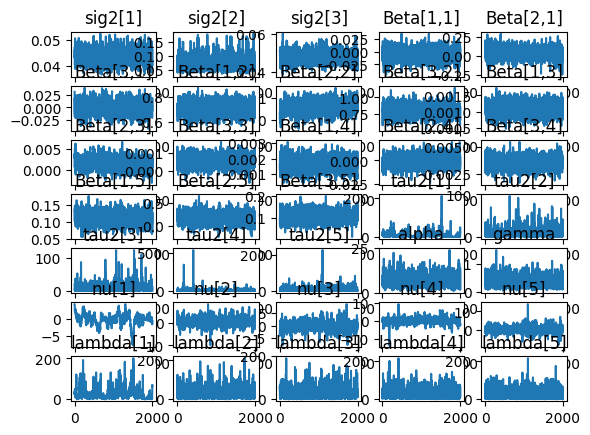

In [37]:
vars = ['sig2[1]',
       'sig2[2]', 'sig2[3]', 'Beta[1,1]', 'Beta[2,1]', 'Beta[3,1]',
       'Beta[1,2]', 'Beta[2,2]', 'Beta[3,2]', 'Beta[1,3]', 'Beta[2,3]',
       'Beta[3,3]', 'Beta[1,4]', 'Beta[2,4]', 'Beta[3,4]', 'Beta[1,5]',
       'Beta[2,5]', 'Beta[3,5]', 'tau2[1]', 'tau2[2]', 'tau2[3]', 'tau2[4]',
       'tau2[5]', 'alpha', 'gamma', 'nu[1]', 'nu[2]', 'nu[3]', 'nu[4]',
       'nu[5]', 'lambda[1]', 'lambda[2]', 'lambda[3]', 'lambda[4]',
       'lambda[5]']
for i in range(35):
    var = vars[i]
    plt.subplot(7, 5, i + 1)
    plt.title(var)
    plt.plot(df[var])

In [47]:
mean_dict = df.groupby('chain__').mean().to_dict()

In [ ]:
data = pd.read_csv('../processed_data/processed_data.csv')
data.columns
basin_dict = {"AL": }

Index(['Date', 'Basin', 'LAT', 'LON', 'AL', 'CP', 'EP', 'VMAX12', 'MSLP12',
       'POT12', 'VMPI12', 'VGRAD0-6', 'VGRAD6-12', 'VMAX36', 'ONI',
       'logVMAX12', 'logMSLP12', 'logPOT12', 'logVMAX36', 'logVMPI12'],
      dtype='object')

In [ ]:
i = 300
row = data.iloc[i]
b = basin_dict[row["Basin"]]
row[["ONI", "logVMAX12", "MSLP12", 'VGRAD6-12', 'POT12', "Basin"]].values

array([np.float64(-0.97), np.float64(3.4011973816621555),
       np.float64(1006.0), np.float64(0.0), np.float64(128.0), 'AL'],
      dtype=object)